# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2574s 15us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

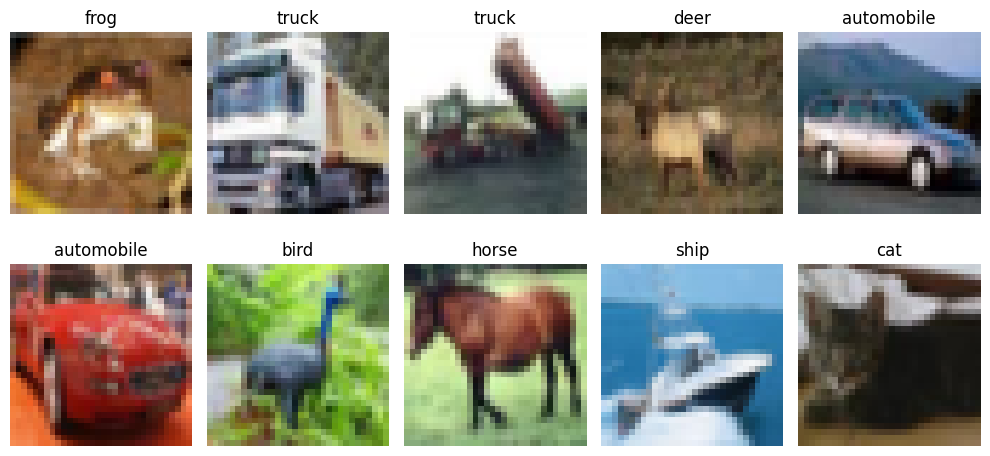

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [12]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.2668 - loss: 1.9941 - val_accuracy: 0.3250 - val_loss: 1.8327
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3180 - loss: 1.8660 - val_accuracy: 0.3606 - val_loss: 1.7827
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3416 - loss: 1.8036 - val_accuracy: 0.3752 - val_loss: 1.7370
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.3580 - loss: 1.7611 - val_accuracy: 0.3974 - val_loss: 1.7065
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3684 - loss: 1.7347 - val_accuracy: 0.3960 - val_loss: 1.7001
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3766 - loss: 1.7135 - val_accuracy: 0.3946 - val_loss: 1.6924
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.3830 - loss: 1.6956 - val_accuracy: 0.4126 - val_loss: 1.6635
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.3883 - loss: 1.6832 - 

In [13]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4210 - loss: 1.6395
ANN Test Accuracy: 0.42100000381469727


In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

### ANN v2 — deeper network to test if more layers improve performance

In [15]:
ann_model_v2 = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history_v2 = ann_model_v2.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.2488 - loss: 2.0210 - val_accuracy: 0.3336 - val_loss: 1.8645
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.3119 - loss: 1.8772 - val_accuracy: 0.3380 - val_loss: 1.8183
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.3328 - loss: 1.8301 - val_accuracy: 0.3538 - val_loss: 1.8024
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.3468 - loss: 1.7896 - val_accuracy: 0.3860 - val_loss: 1.7274
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.3591 - loss: 1.7621 - val_accuracy: 0.3908 - val_loss: 1.7164
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - accuracy: 0.3670 - loss: 1.7400 - val_accuracy: 0.4024 - val_loss: 1.7091
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 38ms/step - accuracy: 0.3702 - loss: 1.7264 - val_accuracy: 0.3964 - val_loss: 1.6763
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.3818 - loss: 1.7058 - 

In [16]:
ann_test_loss_v2, ann_test_acc_v2 = ann_model_v2.evaluate(x_test_flat, y_test)
print("ANN v2 Test Accuracy:", ann_test_acc_v2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4498 - loss: 1.5791
ANN v2 Test Accuracy: 0.4498000144958496


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [17]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 70ms/step - accuracy: 0.4720 - loss: 1.4948 - val_accuracy: 0.5036 - val_loss: 1.4590
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 69ms/step - accuracy: 0.6075 - loss: 1.1207 - val_accuracy: 0.6120 - val_loss: 1.0788
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.6703 - loss: 0.9488 - val_accuracy: 0.6314 - val_loss: 1.0666
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 70ms/step - accuracy: 0.7083 - loss: 0.8371 - val_accuracy: 0.6562 - val_loss: 1.0722
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.7415 - loss: 0.7400 - val_accuracy: 0.7200 - val_loss: 0.8223
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.7690 - loss: 0.6608 - val_accuracy: 0.7288 - val_loss: 0.8040
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 70ms/step - accuracy: 0.7910 - loss: 0.5914 - val_accuracy: 0.6582 - val_loss: 1.1154
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.8130 - loss: 0.5314 - 

In [18]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7144 - loss: 0.9618
CNN Test Accuracy: 0.7143999934196472


### CNN v2 — increased filters (64→128→256) to test deeper feature extraction

In [19]:
cnn_model_v2 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_v2 = cnn_model_v2.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 201ms/step - accuracy: 0.4389 - loss: 1.5556 - val_accuracy: 0.5246 - val_loss: 1.2899
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 204ms/step - accuracy: 0.5967 - loss: 1.1555 - val_accuracy: 0.5966 - val_loss: 1.1681
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - accuracy: 0.6679 - loss: 0.9560 - val_accuracy: 0.5732 - val_loss: 1.3875
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 200ms/step - accuracy: 0.7150 - loss: 0.8235 - val_accuracy: 0.6602 - val_loss: 0.9792
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - accuracy: 0.7542 - loss: 0.7073 - val_accuracy: 0.7110 - val_loss: 0.8263
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 206ms/step - accuracy: 0.7854 - loss: 0.6104 - val_accuracy: 0.6974 - val_loss: 0.9225
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 202ms/step - accuracy: 0.8140 - loss: 0.5271 - val_accuracy: 0.6432 - val_loss: 1.1503
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 203ms/step - accuracy: 0.8364 -

In [20]:
cnn_test_loss_v2, cnn_test_acc_v2 = cnn_model_v2.evaluate(x_test_norm, y_test)
print("CNN v2 Test Accuracy:", cnn_test_acc_v2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7496 - loss: 1.0162
CNN v2 Test Accuracy: 0.7495999932289124


## 📈 Compare Learning Curves

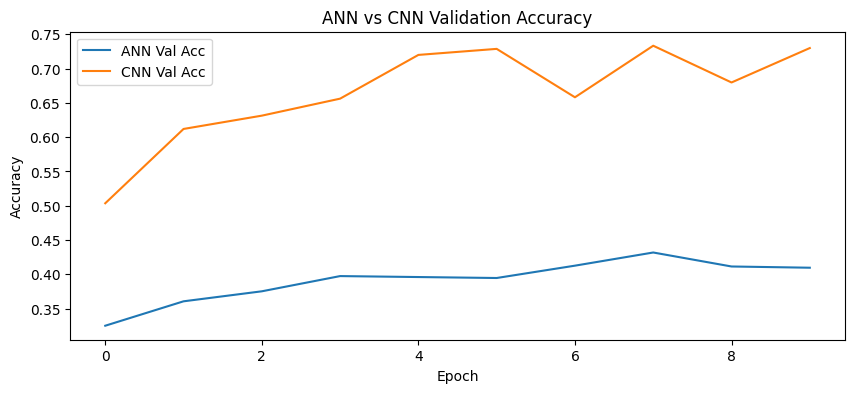

In [21]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [22]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

### Train the CNN with data augmentation enabled

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop_aug = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 54ms/step - accuracy: 0.4498 - loss: 1.5262 - val_accuracy: 0.4958 - val_loss: 1.3906
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.4860 - loss: 1.4343 - val_accuracy: 0.5308 - val_loss: 1.2748
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.5126 - loss: 1.3676 - val_accuracy: 0.5718 - val_loss: 1.2405
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.5282 - loss: 1.3238 - val_accuracy: 0.5748 - val_loss: 1.2086
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.5492 - loss: 1.2743 - val_accuracy: 0.5918 - val_loss: 1.1569
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.5560 - loss: 1.2502 - val_accuracy: 0.5798 - val_loss: 1.1966
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.5692 - loss: 1.2236 - val_accuracy: 0.6114 - val_loss: 1.0858
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.5772 - loss: 1.2049 - 

In [27]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6685 - loss: 0.9667
Augmented CNN Test Accuracy: 0.6685000061988831


# 📊 Final Comparison Table
## Updated comparison across all model versions

In [28]:
comparison = pd.DataFrame({
    "Model": ["ANN", "ANN v2", "CNN", "CNN v2", "CNN + Augmentation"],
    "Test Accuracy": [
        ann_test_acc, ann_test_acc_v2,
        cnn_test_acc, cnn_test_acc_v2,
        aug_test_acc
    ]
})
comparison

,Model,Test Accuracy
0,ANN,0.4210
1,ANN v2,0.4498
2,CNN,0.7144
3,CNN v2,0.7496
4,CNN + Augmentation,0.6685


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

### 📝 Note on Additions

I have added new cells throughout this notebook to complete the **Student Learning Tasks** mentioned above:

1. ✅ Added `ann_model_v2` with deeper layers to observe ANN performance with more depth
2. ✅ Added `cnn_model_v2` with increased filters (64→128→256) for deeper feature extraction
3. ✅ Increased epochs to 20 for both v2 models
4. ✅ Added an `EarlyStopping` callback to prevent overfitting and save training time
5. ✅ Enabled and trained the data augmentation model (`aug_cnn_model`)

All original cells were left unchanged, and the new cells were added directly after their related sections so the notebook still reads top-to-bottom in a logical order. The final comparison table was updated to include all five model variants.